# Deep Operator Network (DeepONets) in Neuromancer: Learning nonlinear operators

This tutorial demonstrates the use of Deep Operator Network (DeepONets) for solving partial differential equations (PDEs) in the Neuromancer library.


<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs42256-021-00302-5/MediaObjects/42256_2021_302_Fig1_HTML.png" width="700">  


### References

[1] [Lu, L., Jin, P., Pang, G. et al. Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators. Nat Mach Intell 3, 218–229 (2021).](https://www.nature.com/articles/s42256-021-00302-5)

[2] https://github.com/jdtoscano94/Learning-Python-Physics-Informed-Machine-Learning-PINNs-DeepONets/tree/main

[3] [Lu, L., Meng, X., Cai, S., Mao, Z., Goswami, S., Zhang, Z., & Karniadakis, G. E. (2022). A comprehensive and fair comparison of two neural operators (with practical extensions) based on fair data. Computer Methods in Applied Mechanics and Engineering, 393, 114778.](https://www.sciencedirect.com/science/article/pii/S0045782522001207?via%3Dihub)

[4] https://docs.nvidia.com/physicsnemo/25.08/physicsnemo-sym/user_guide/neural_operators/deeponet.html

## Install (Colab only)
Skip this step when running locally.

In [1]:
# !pip install neuromancer
# !pip install pyDOE

*Note: When running on Colab, one might encounter a pip dependency error with Lida 0.0.10. This can be ignored*

## Imports

In [2]:
import os
import time

# torch and numpy imports
import torch
import torch.nn as nn
import numpy as np

# plotting imports
import matplotlib.pyplot as plt

# filter some user warnings from torch broadcast
import warnings

warnings.filterwarnings("ignore")

# DeepXDE library
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# Set default dtype to float32
torch.set_default_dtype(torch.float)
# PyTorch random number generator
torch.manual_seed(1234)

# Random number generators in other libraries
np.random.seed(1234)

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Problem Setup

original source: https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/diffusion.1d.html

**Diffusion equation**

$$\frac{\partial y}{\partial t} =\frac{\partial^2 y}{\partial x^2}-e^{-t}(sin(\pi x)-\pi^2 sin(\pi x))$$

$$x\in[-1,1]$$
$$t\in[0,1]$$

**Initial Condition:**

$$y(x,0)=sin(\pi x)$$

**Boundary Conditions:**

$$y(-1,t)=0$$
$$y(1,t)=0$$

**Exact solution:**

$$y(x,t)=e^{-t}sin(\pi x)$$

### Generate data of the exact solution

In [4]:
# exact solution y(x,t)
def f_real(x, t):
    return torch.exp(-t) * (torch.sin(np.pi * x))


# define range of the space and time variables:
x_min = -1
x_max = 1
t_min = 0
t_max = 1

# define number of spatial and temporal points
total_points_x = 200
total_points_t = 100

# generate samples of x, t
x = torch.linspace(x_min, x_max, total_points_x, device=device).view(-1, 1)
t = torch.linspace(t_min, t_max, total_points_t, device=device).view(-1, 1)

# Create the mesh of x, t
X, T = torch.meshgrid(x.squeeze(1), t.squeeze(1), indexing="ij")

# Evaluate exact solution y(x,t) on the mesh
y_real = f_real(X, T)

# data shapes
print(x.shape, t.shape)
print(X.shape, T.shape, y_real.shape)

torch.Size([200, 1]) torch.Size([100, 1])
torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])


In [5]:
# min and max values of the PDE solution
ymin = y_real.min()
ymax = y_real.max()
print(ymin, ymax)

tensor(-1.0000, device='cuda:0') tensor(1.0000, device='cuda:0')


### Plot the exact solution

In [6]:
def plot3D(X, T, y):
    # Move everything to CPU once
    Xc = X.detach().cpu().numpy()
    Tc = T.detach().cpu().numpy()
    yc = y.detach().cpu().numpy()

    fig = plt.figure(figsize=(12, 5))

    # 2D contour
    ax1 = fig.add_subplot(121)
    cm = ax1.contourf(Tc, Xc, yc, 20, cmap="viridis")
    fig.colorbar(cm, ax=ax1)
    ax1.set_title("y(x,t)")
    ax1.set_xlabel("t")
    ax1.set_ylabel("x")
    ax1.set_aspect("equal")

    # 3D surface
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.plot_surface(Tc, Xc, yc, cmap="viridis")
    ax2.set_xlabel("t")
    ax2.set_ylabel("x")
    ax2.set_zlabel("y(x,t)")

    fig.tight_layout()


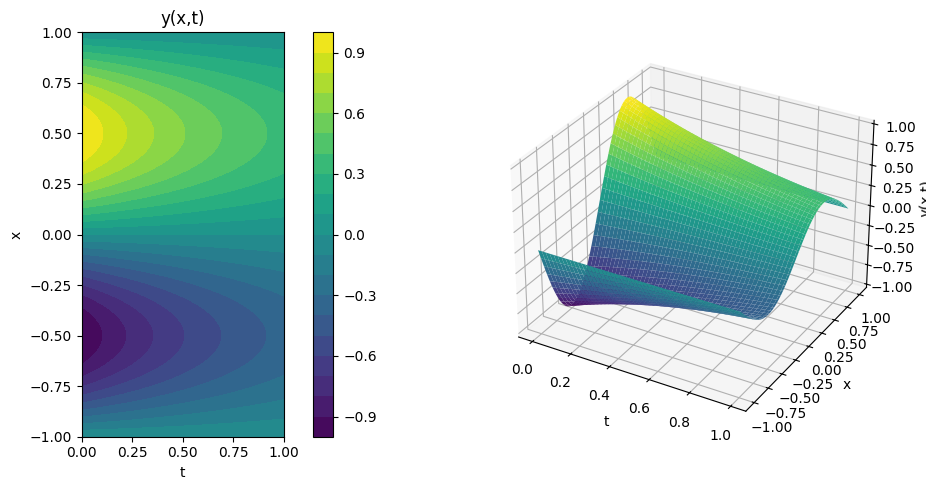

In [7]:
plot3D(X, T, y_real)

### Test data: exact PDE solution

In [8]:
# Transform the mesh into a 2-column vector
X_test = X.transpose(1, 0).flatten()[:, None].float()  # the input dataset of x
T_test = T.transpose(1, 0).flatten()[:, None].float()  # the input dataset of t
Y_test = (
    y_real.transpose(1, 0).flatten()[:, None].float()
)  # the real solution over (x,t)
print(X_test.shape, T_test.shape, Y_test.shape)

torch.Size([20000, 1]) torch.Size([20000, 1]) torch.Size([20000, 1])


##  Construct training datasets

We construct training and development datasets containing [collocation points (CP)](https://en.wikipedia.org/wiki/Collocation_method) of the spatio-temporal domain (x,t), and samples of the [initial conditions (IC)](https://en.wikipedia.org/wiki/Initial_condition), and [boundary conditions (BC)](https://en.wikipedia.org/wiki/Boundary_value_problem).

The dataset is given as:
$\Xi_{\text{train/dev}} = [\texttt{CP}^i, \texttt{IC}^j, \texttt{BC}^j]$, $i = 1,...,N_f$, $j = 1,...,N_u$  
Where $N_f$ defines number of collocation points, and $N_u$ number of initial and boundary condition samples.

### Samples of Initial Condition (IC)

In [9]:
#   Left Edge: y(x,0) = sin(pi*x)
left_X = X[:, [0]]
left_T = T[:, [0]]
left_Y = torch.sin(np.pi * left_X[:, 0]).unsqueeze(1)
print(left_X.shape, left_T.shape, left_Y.shape)

torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])


### Samples of Boundary Conditions (BC)

In [10]:
#   Bottom Edge: x=min; tmin=<t=<max
bottom_X = X[[0], :].T
bottom_T = T[[0], :].T
bottom_Y = torch.zeros(bottom_X.shape[0], 1, device=device)
print(bottom_X.shape, bottom_T.shape, bottom_Y.shape)
#   Top Edge: x=max; 0=<t=<1
top_X = X[[-1], :].T
top_T = T[[-1], :].T
top_Y = torch.zeros(top_X.shape[0], 1, device=device)
print(top_X.shape, top_T.shape, top_Y.shape)

torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1])
torch.Size([100, 1]) torch.Size([100, 1]) torch.Size([100, 1])


### Number of training samples for IC and BC

In [11]:
# Get all the initial and boundary condition data
X_train = torch.vstack([left_X, bottom_X, top_X])
T_train = torch.vstack([left_T, bottom_T, top_T])
Y_train = torch.vstack([left_Y, bottom_Y, top_Y])
print(X_train.shape, T_train.shape, Y_train.shape)

# Choose (Nu) Number of training points for initial and boundary conditions
Nu = 200

# Randomly sample Nu points of our available initial and boundary condition data:
idx = np.sort(np.random.choice(X_train.shape[0], Nu, replace=False))
X_train_Nu = X_train[idx, :].float()  # Training Points  of x at (IC+BC)
T_train_Nu = T_train[idx, :].float()  # Training Points  of t at (IC+BC)
Y_train_Nu = Y_train[idx, :].float()  # Training Points  of y at (IC+BC)
print(X_train_Nu.shape, T_train_Nu.shape, Y_train_Nu.shape)

torch.Size([400, 1]) torch.Size([400, 1]) torch.Size([400, 1])
torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])


### Samples of Collocation Points (CP)

In [12]:
# x Domain bounds
x_lb = X_test[0]  # first value
x_ub = X_test[-1]  # last value
print(x_lb, x_ub)

# t Domain bounds
t_lb = T_test[0]  # first value
t_ub = T_test[-1]  # last value
print(t_lb, t_ub)

#  Choose (Nf) Collocation Points to Evaluate the PDE on
Nf = 1000  # Nf: Number of collocation points (Evaluate PDE)

# generate collocation points (CP)
# X_train_CP = torch.FloatTensor(Nf, 1).uniform_(float(x_lb), float(x_ub))
# T_train_CP = torch.FloatTensor(Nf, 1).uniform_(float(t_lb), float(t_ub))
X_train_CP = torch.empty(Nf, 1, device=device).uniform_(x_lb.item(), x_ub.item())
T_train_CP = torch.empty(Nf, 1, device=device).uniform_(t_lb.item(), t_ub.item())
y_train_cp = f_real(X_train_CP, T_train_CP)
Y_train_CP = y_train_cp.reshape(-1, 1).float()  # the real solution over (x,t)
print(X_train_CP.shape, T_train_CP.shape, Y_train_CP.shape)

# add IC+BC to the collocation points
X_train_Nf = torch.vstack(
    (X_train_CP, X_train_Nu)
).float()  # Collocation Points of x (CP)
T_train_Nf = torch.vstack(
    (T_train_CP, T_train_Nu)
).float()  # Collocation Points of t (CP)
Y_train_Nf = torch.vstack(
    (Y_train_CP, Y_train_Nu)
).float()  # Collocation Points of t (CP)
print(X_train_Nf.shape, T_train_Nf.shape, Y_train_Nf.shape)

tensor([-1.], device='cuda:0') tensor([1.], device='cuda:0')
tensor([0.], device='cuda:0') tensor([1.], device='cuda:0')
torch.Size([1000, 1]) torch.Size([1000, 1]) torch.Size([1000, 1])
torch.Size([1200, 1]) torch.Size([1200, 1]) torch.Size([1200, 1])


In [13]:
print("Original shapes for X, T, and Y:", X.shape, T.shape, y_real.shape)
print(
    "Initial and Boundary condition shapes for X:",
    left_X.shape,
    bottom_X.shape,
    top_X.shape,
)
print(
    "Initial and Boundary condition shapes for T:",
    left_T.shape,
    bottom_T.shape,
    top_T.shape,
)
print(
    "Available training data of IC and BC (X,T,Y):",
    X_train.shape,
    T_train.shape,
    Y_train.shape,
)
print(
    "Selected training data of IC and BC (X,T,Y):",
    X_train_Nu.shape,
    T_train_Nu.shape,
    Y_train_Nu.shape,
)
print(
    "Final training data of CP (X,T,Y):",
    X_train_Nf.shape,
    T_train_Nf.shape,
    Y_train_Nf.shape,
)
print("Final test data (X,T,Y):", X_test.shape, T_test.shape, Y_test.shape)

Original shapes for X, T, and Y: torch.Size([200, 100]) torch.Size([200, 100]) torch.Size([200, 100])
Initial and Boundary condition shapes for X: torch.Size([200, 1]) torch.Size([100, 1]) torch.Size([100, 1])
Initial and Boundary condition shapes for T: torch.Size([200, 1]) torch.Size([100, 1]) torch.Size([100, 1])
Available training data of IC and BC (X,T,Y): torch.Size([400, 1]) torch.Size([400, 1]) torch.Size([400, 1])
Selected training data of IC and BC (X,T,Y): torch.Size([200, 1]) torch.Size([200, 1]) torch.Size([200, 1])
Final training data of CP (X,T,Y): torch.Size([1200, 1]) torch.Size([1200, 1]) torch.Size([1200, 1])
Final test data (X,T,Y): torch.Size([20000, 1]) torch.Size([20000, 1]) torch.Size([20000, 1])


### Plot collocation points

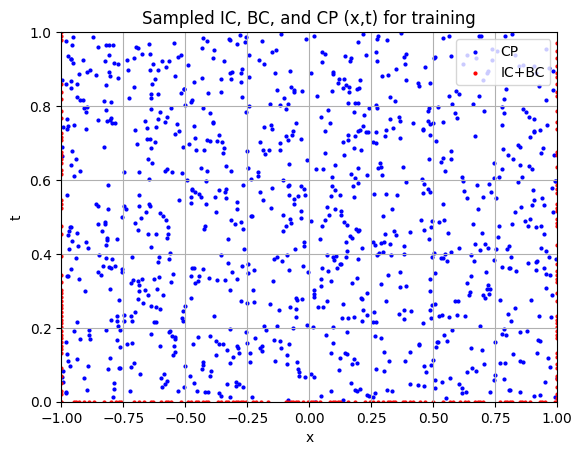

In [14]:
# visualize collocation points for 2D input space (x, t)
plt.figure()
plt.scatter(
    X_train_CP.detach().cpu().numpy(),
    T_train_CP.detach().cpu().numpy(),
    s=4.0,
    c="blue",
    marker="o",
    label="CP",
)
plt.scatter(
    X_train_Nu.detach().cpu().numpy(),
    T_train_Nu.detach().cpu().numpy(),
    s=4.0,
    c="red",
    marker="o",
    label="IC+BC",
)
plt.title("Sampled IC, BC, and CP (x,t) for training")
plt.xlim(x_lb.detach().cpu().item(), x_ub.detach().cpu().item())
plt.ylim(t_lb.detach().cpu().item(), t_ub.detach().cpu().item())
plt.grid(True)
plt.xlabel("x")
plt.ylabel("t")
plt.legend(loc="upper right")
plt.show()
plt.show(block=True)

### Create Neuromancer datasets for DeepONet

Minimal recipe with your data (one function):

- Pick m points along x (say m=50) and build branch_vec of shape (m,) from your input function at those x’s.
- Trunk: trunk = np.hstack([X_all, T_all]) → shape (N, 2) with N=200+1200.
- Branch tiled: branch = np.tile(branch_vec, (N, 1)) → shape (N, m).
- Targets: y = Y_all → shape (N, 1).

In [15]:
# DeepONet data prep: branch (m sensors at t=0) + trunk (x,t) + targets (y)
from neuromancer.dataset import DictDataset

N = X_train_Nf.shape[0]  # 1200
m = 50  # number of sensors along t=0

# Use the initial-condition line (t=0).
# If you want x = x_min instead, swap left_* for bottom_*.
sensor_idx = np.sort(np.random.choice(left_X.shape[0], size=m, replace=False))
branch_vec = left_Y[sensor_idx, 0].float()  # (m,)
branch_inputs = branch_vec.unsqueeze(0).repeat(N, 1)  # (N, m)

# Trunk coordinates are the collocation points (x, t)
trunk_inputs = torch.cat([X_train_Nf, T_train_Nf], dim=1)  # (N, 2)
outputs = Y_train_Nf  # (N, 1)

deeponet_train = DictDataset(
    {
        "branch_inputs": branch_inputs,
        "trunk_inputs": trunk_inputs,
        "outputs": outputs,
    },
    name="train",
)

print(
    f"branch_vec {branch_vec.shape}, "
    f"branch_inputs {branch_inputs.shape}, "
    f"trunk_inputs {trunk_inputs.shape}, "
    f"outputs {outputs.shape}"
)


branch_vec torch.Size([50]), branch_inputs torch.Size([1200, 50]), trunk_inputs torch.Size([1200, 2]), outputs torch.Size([1200, 1])


In [16]:
N_test = X_test.shape[0]

# New sensor locations for the branch (shifted midpoints so they differ from training grid)
sensor_x_test = (x_min + (x_max - x_min) * torch.rand(m)).sort().values
branch_vec_test = f_real(sensor_x_test, torch.zeros_like(sensor_x_test)).float()  # (m,)
branch_inputs_test = branch_vec_test.unsqueeze(0).repeat(N_test, 1)  # (N_test, m)

# Trunk points: use the test grid (x,t) -> (N_test, 2)
trunk_inputs_test = torch.cat([X_test, T_test], dim=1).float()  # (N_test, 2)

# Targets at those trunk points
outputs_test = Y_test.float()  # (N_test, 1)

deeponet_test = DictDataset(
    {
        "branch_inputs": branch_inputs_test,
        "trunk_inputs": trunk_inputs_test,
        "outputs": outputs_test,
    },
    name="test",
)

print(
    f"branch_vec {branch_vec_test.shape}, "
    f"branch_inputs {branch_inputs_test.shape}, "
    f"trunk_inputs {trunk_inputs_test.shape}, "
    f"outputs {outputs_test.shape}"
)

branch_vec torch.Size([50]), branch_inputs torch.Size([20000, 50]), trunk_inputs torch.Size([20000, 2]), outputs torch.Size([20000, 1])


In [17]:
# Optional loader
train_loader = torch.utils.data.DataLoader(
    deeponet_train,
    batch_size=N,  # full batch; change as needed
    collate_fn=deeponet_train.collate_fn,
    shuffle=False,
)

# Optional loader
test_loader = torch.utils.data.DataLoader(
    deeponet_test, batch_size=N, collate_fn=deeponet_test.collate_fn, shuffle=False
)

# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[Nu, 128, 128, p]`, where `p=32` and the trunk net is a fully connected neural network of size `[dim_x, 128, 128, p]`, where `dim_x` is dimension i.e. 2 (x,t).

We use `dde.nn.DeepONet` to create the DeepONet directly for DeepXDE library. This is a generic DeepONet implementation needing a list of triple (function_sample, location, target_value)
(MLP architecture the same as https://github.com/lululxvi/deepxde/blob/master/examples/operator/advection_aligned_pideeponet_2d.py)

In [18]:
dim_x = 2  # dimension of the input (x,t) to the trunk net
p = 128

dde_DeepOnet = dde.nn.DeepONet(
    [m, 128, 128, p],
    [dim_x, 128, 128, p],
    activation="tanh",
    kernel_initializer="Glorot normal",
)


A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [ ]:
class DeepONetBatchWrapper(nn.Module):
    """
    Adapter for DeepONet-style models that keeps the default DictDataset/DataLoader collate.

    Call modes:
      1) forward(batch_dict): expects keys
         - branch_inputs: (B, m)
         - trunk_inputs:  (B, dim_x) or (B, m, dim_x); if 3D we assume a shared grid and take trunk_inputs[0]
         - outputs:       (B, 1) [optional]
      2) forward(branch, trunk, targets=None): positional tensors, targets optional

    Returns:
      - preds if no targets are provided
      - (preds, targets) if targets are present
    """

    def __init__(
        self,
        model: nn.Module,
        branch_key: str = "branch_inputs",
        trunk_key: str = "trunk_inputs",
        output_key: str = "outputs",
    ) -> None:
        super().__init__()
        self.model = model
        self.branch_key = branch_key
        self.trunk_key = trunk_key
        self.output_key = output_key

    def forward(self, *args, **kwargs):
        # Case 1: single dict batch
        if len(args) == 1 and isinstance(args[0], dict):
            batch = args[0]
            branch = batch[self.branch_key]
            trunk = batch[self.trunk_key]
            targets = batch.get(self.output_key)
        # Case 2: branch, trunk passed separately
        elif len(args) == 2:
            branch, trunk = args
            targets = kwargs.get("targets")
        else:
            raise TypeError(
                "Expected forward(batch_dict) or forward(branch, trunk); "
                f"got {len(args)} positional args."
            )

        if trunk.dim() == 3:  # (B, m, dim_x) → shared grid
            trunk = trunk[0]

        preds = self.model((branch, trunk))
        return (preds, targets) if targets is not None else preds


In [ ]:
from neuromancer.system import Node
from neuromancer.modules.operators import DeepXDEWrapper

dde_DeepOnet_wrapped = DeepXDEWrapper(dde_DeepOnet)

node_dde_deeponet = Node(
    dde_DeepOnet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_DeepOnet",
)
print(node_dde_deeponet)

dde_DeepOnet(branch_inputs, trunk_inputs) -> g


# Generate H1 and L2 loss for loss evaluation 
We use H1 loss for training and L2 loss for evaluation H1 loss is particularly good for PDE problems as it penalizes both function values and gradients

## L2 norm

$$
\|y - y_h\|_{L^2(\Omega)}^2.
$$

## H1 norm

$$
\|y - y_h\|_{H^1(\Omega)}^2
=
\|y - y_h\|_{L^2(\Omega)}^2
+
\|y_x - y_{h,x}\|_{L^2(\Omega)}^2
+
\|y_t - y_{h,t}\|_{L^2(\Omega)}^2.
$$

In [ ]:
from neuromancer.constraint import variable

# y_true, y_hat: B x 1 vectors from your datadict
y_true = variable("g")  # B x 1
y_hat = variable("outputs")  # B x 1

# Option 1: keep the last dim (result will be (B-1, 1))
dx_hat = y_hat[1:, :] - y_hat[:-1, :]  # \hat{f}(x_{i+1}) - \hat{f}(x_i)
dx_true = y_true[1:, :] - y_true[:-1, :]  # f(x_{i+1}) - f(x_i

In [35]:
# Value (L2) match and gradient (L2) matches; ^2 sets the L2 norm
val_constraint = (y_hat == y_true) ^ 2
val_constraint.update_name("residual_loss")

grad_constraint = (dx_hat == dx_true) ^ 2
grad_constraint.update_name("grad_loss")

In [36]:
from neuromancer.problem import Problem
from neuromancer.loss import PenaltyLoss

var_y_est = variable("g")
var_y_true = variable("outputs")

nodes = [node_dde_deeponet]

# var_loss = (var_y_est == var_y_true.T) ^ 2 # this line caused issue, dont need to transpose with return_transposed=True
var_loss = (var_y_est == var_y_true) ^ 2
var_loss.name = "residual_loss"
objectives = [val_constraint, grad_constraint]
# objectives = [l2_obj]


loss = PenaltyLoss(objectives, constraints=[])

problem = Problem(nodes, loss=loss, grad_inference=True)

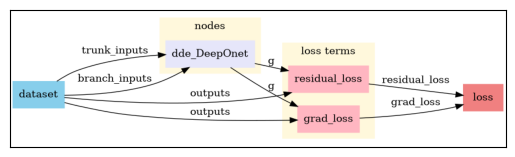

In [37]:
problem.show()

##  Train the PINN to solve the PDE

We use stochastic gradient descent to optimize the parameters $\theta$ of the neural network $NN_{\theta}(t,x)$ approximating the solution to the PDE equation $y(t,x)$ using the PINN loss $\ell_{\text{PINN}}$ evaluated over sampled CP, IP, and BC.

### Construct Trainer and solve the problem  

In [38]:
from neuromancer.trainer import Trainer

optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)
epochs = 500

#  Neuromancer trainer
trainer = Trainer(
    problem.to(device),
    train_loader,
    optimizer=optimizer,
    epochs=epochs,
    epoch_verbose=10,
    train_metric="train_loss",
    dev_metric="train_loss",
    eval_metric="train_loss",
    warmup=epochs,
    device=device,
)

In [39]:
# Train PINN
best_model = trainer.train()

# load best trained model
problem.load_state_dict(best_model)

epoch: 0  train_loss: 0.007830588147044182
epoch: 10  train_loss: 0.8029553890228271
epoch: 20  train_loss: 0.2940373420715332
epoch: 30  train_loss: 0.186290442943573
epoch: 40  train_loss: 0.12246771156787872
epoch: 50  train_loss: 0.07006516307592392
epoch: 60  train_loss: 0.03235387057065964
epoch: 70  train_loss: 0.01464737020432949
epoch: 80  train_loss: 0.010557856410741806
epoch: 90  train_loss: 0.00888444110751152
epoch: 100  train_loss: 0.007826484739780426
epoch: 110  train_loss: 0.00772253330796957
epoch: 120  train_loss: 0.007599290460348129
epoch: 130  train_loss: 0.007432331796735525
epoch: 140  train_loss: 0.007312634028494358
epoch: 150  train_loss: 0.007191247306764126
epoch: 160  train_loss: 0.007066693156957626
epoch: 170  train_loss: 0.006939982995390892
epoch: 180  train_loss: 0.006809750571846962
epoch: 190  train_loss: 0.006676592864096165
epoch: 200  train_loss: 0.006540394388139248
epoch: 210  train_loss: 0.006401266902685165
epoch: 220  train_loss: 0.00625937

<All keys matched successfully>

## Plots

In [40]:
# evaluate trained PINN on test data
fno_out = problem.nodes[0].to(device)
y1 = fno_out(deeponet_test.datadict)["g"]

# arrange data for plotting on the test grid
y_fno = y1.reshape(shape=[200, 100]).detach().cpu()

In [41]:
y1.shape

torch.Size([20000, 1])

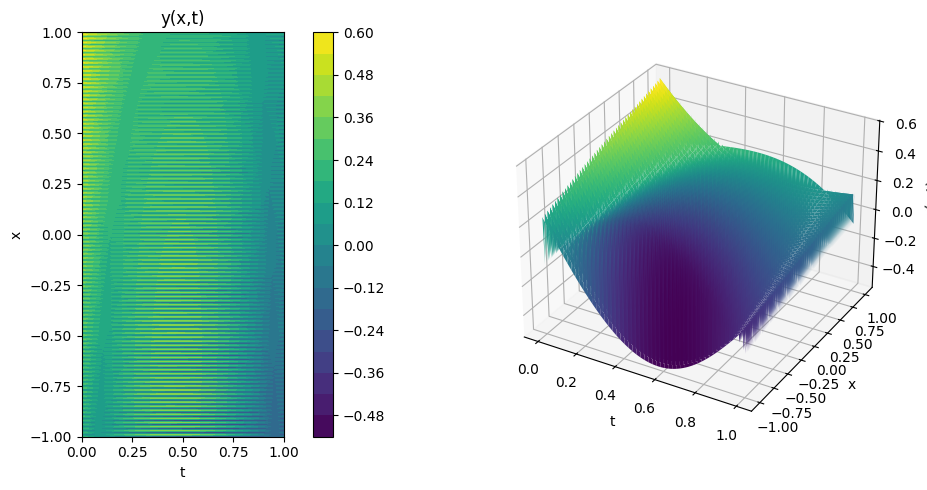

In [42]:
# plot PINN solution
plot3D(X, T, y_fno)

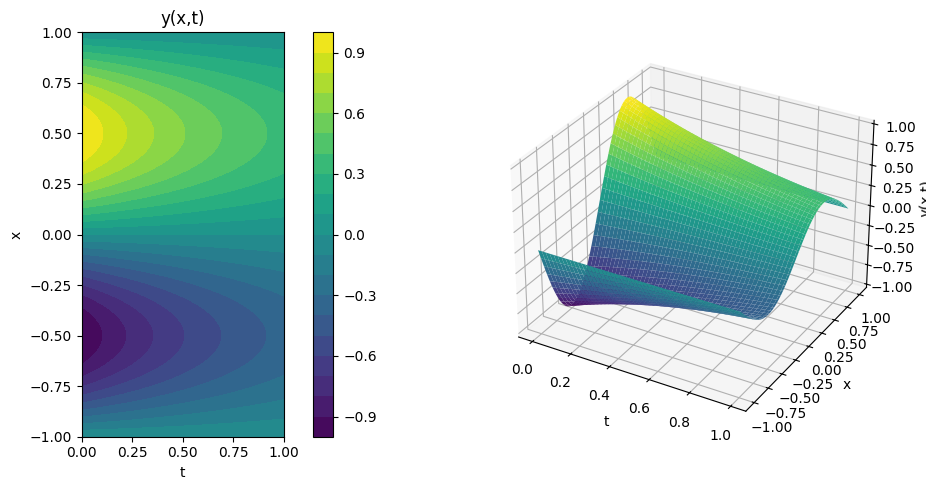

In [43]:
# plot exact PDE solution
plot3D(X, T, y_real)

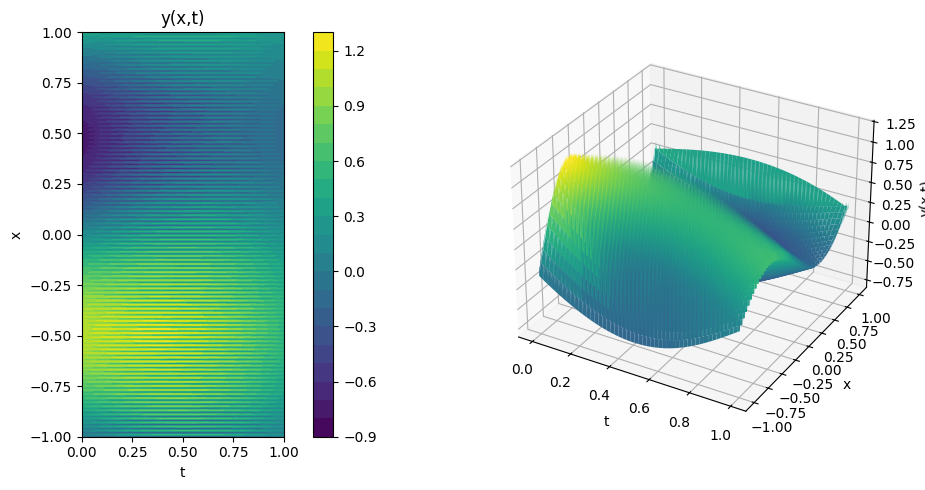

In [29]:
# plot residuals PINN - exact PDE
plot3D(X, T, y_fno - y_real.detach().cpu())